In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/animal-bites/Health_AnimalBites.csv
/kaggle/input/dog-breeds/dog_breeds.csv


In [2]:
assets_folder = '/kaggle/input'
dog_breeds = pd.read_csv(f'{assets_folder}/dog-breeds/dog_breeds.csv')
print(dog_breeds['Breed'].unique())
dog_breeds.head()


['Labrador Retriever' 'German Shepherd' 'Bulldog' 'Poodle' 'Beagle'
 'Chihuahua' 'Boxer' 'Golden Retriever' 'Pug' 'Rottweiler'
 'Siberian Husky' 'Dachshund' 'Shih Tzu' 'Bichon Frise'
 'Australian Shepherd' 'Basset Hound' 'Cocker Spaniel' 'French Bulldog'
 'Pomeranian' 'Great Dane' 'Mastiff' 'Newfoundland' 'Saint Bernard'
 'Old English Sheepdog' 'Irish Wolfhound' 'Greyhound' 'Scottish Deerhound'
 'Great Pyrenees' 'Shar Pei' 'Doberman Pinscher' 'Weimaraner'
 'Belgian Malinois' 'Rhodesian Ridgeback' 'English Setter' 'Pointer'
 'Gordon Setter' 'Irish Setter' 'Papillon' 'Pekingese' 'Toy Poodle'
 'Miniature Poodle' 'Standard Poodle' 'Affenpinscher' 'Boston Terrier'
 'Brussels Griffon' 'Cairn Terrier' 'Chinese Crested'
 'Miniature Schnauzer' 'Standard Schnauzer' 'West Highland White Terrier'
 'Australian Terrier' 'Border Terrier' 'Coton de Tulear'
 'English Toy Spaniel' 'Australian Stumpy Tail Cattle Dog'
 'American Eskimo Dog' 'Australian Cattle Dog' 'Australian Kelpie'
 'Bloodhound' 'Border

,Breed,Country of Origin,Fur Color,Height (in),Color of Eyes,Longevity (yrs),Character Traits,Common Health Problems
0,Labrador Retriever,Canada,"Yellow, Black, Chocolate",21-24,Brown,10-12,"Loyal, friendly, intelligent, energetic, good-...","Hip dysplasia, obesity, ear infections"
1,German Shepherd,Germany,"Black, Tan",22-26,Brown,7-10,"Loyal, intelligent, protective, confident, tra...","Hip dysplasia, elbow dysplasia, pancreatitis"
2,Bulldog,England,"White, Red",12-16,Brown,8-10,"Loyal, calm, gentle, brave","Skin allergies, respiratory issues, obesity"
3,Poodle,France,"White, Black, Brown, Apricot",10-15,"Brown, Blue",12-15,"Intelligent, active, affectionate, hypoallergenic","Hip dysplasia, epilepsy, bladder stones"
4,Beagle,England,"White, Tan, Red, Lemon",13-15,Brown,12-15,"Curious, friendly, energetic, good-natured","Ear infections, hip dysplasia, epilepsy"


In [3]:
animal_bites = pd.read_csv(f'{assets_folder}/animal-bites/Health_AnimalBites.csv')
print(animal_bites['BreedIDDesc'].unique())
animal_bites


[nan 'GERM SHEPHERD' 'DACHSHUND' 'PIT BULL' 'SHIH TZU' 'COCKER SPAINEL'
 'CHICHAUHUA' 'BEAGLE' 'CHOW CHOW' 'OTHER' 'BOXER' 'AAUST. TERR.'
 'GOLD RETRIEVER' 'LABRADOR RETRIV' 'BULLMASTIFF' 'BORDER COLLIE'
 'POMERANIAN' 'YORKSHIRE TERRIER' 'GREYHOUND' 'ROTTWEILER'
 'AMER. BULL DOG' 'DALMATIAN' 'HUSKY' 'BULL DOG' 'MASTIF'
 'GREAT PYRENEESE' 'GREAT DANE' 'POODLE' 'SIBERAN HUSKY' 'WEIMARANER'
 'CORGI' 'BOSTON TERRIER' 'SCHNAUZER' 'BASSET HOUND' 'MIN PIN'
 'WELSH CORGI' 'AM BULLDOG' 'SAMOYED' 'MALTASE' 'AKITA' 'SHELTIE'
 'LHASA APSO' 'SAINT BERNARD' 'AIREDALE TER.' 'AM. ESKIMO' 'BICHON FRISE'
 'PUG' 'DOBERMAN' 'DOTSON' 'NEW FOUNDLAND' 'BERNESEN MT.' 'HAVANESE'
 'ENGLISH SETTER' 'SHAR-PEI' 'COCKAPOO' 'OLD ENG SHP DOG' 'WESTIE'
 'BOUVIER' 'RAT TERRIER' 'SHEEP DOG' 'HEELER' 'PEKINGESE'
 'FOX TERRIER MIX' 'ENGLISH BULLDOG' 'BORDER COLLIE M' 'BASANJI' 'PYRENES'
 'BLOOD HOUND' 'COLLIE' 'ALASK. MALAMUTE' 'BRITNEY SPANIEL' 'BICHON FRESE'
 'FOX TERRIER' 'BLUE HEELER' 'CATAHOULA' 'CANE CORSO' 'IRISH S

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,bite_date,SpeciesIDDesc,BreedIDDesc,GenderIDDesc,color,vaccination_yrs,vaccination_date,victim_zip,AdvIssuedYNDesc,WhereBittenIDDesc,quarantine_date,DispositionIDDesc,head_sent_date,release_date,ResultsIDDesc
0,1985-05-05 00:00:00,DOG,NaN,FEMALE,LIG. BROWN,1.0,1985-06-20 00:00:00,40229,NO,BODY,1985-05-05 00:00:00,UNKNOWN,NaN,NaN,UNKNOWN
1,1986-02-12 00:00:00,DOG,NaN,UNKNOWN,BRO & BLA,NaN,NaN,40218,NO,BODY,1986-02-12 00:00:00,UNKNOWN,NaN,NaN,UNKNOWN
2,1987-05-07 00:00:00,DOG,NaN,UNKNOWN,NaN,NaN,NaN,40219,NO,BODY,1990-05-07 00:00:00,UNKNOWN,NaN,NaN,UNKNOWN
3,1988-10-02 00:00:00,DOG,NaN,MALE,BLA & BRO,NaN,NaN,NaN,NO,BODY,1990-10-02 00:00:00,UNKNOWN,NaN,NaN,UNKNOWN
4,1989-08-29 00:00:00,DOG,NaN,FEMALE,BLK-WHT,NaN,NaN,NaN,NO,BODY,NaN,UNKNOWN,NaN,NaN,UNKNOWN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8998,2017-09-05 00:00:00,DOG,NaN,NaN,NaN,NaN,NaN,40243,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN
8999,2017-09-07 00:00:00,DOG,POMERANIAN,MALE,RED,NaN,NaN,40204,NaN,HEAD,NaN,NaN,NaN,NaN,NaN
9000,2017-09-07 00:00:00,DOG,LABRADOR RETRIV,MALE,BROWN,NaN,NaN,47130,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN
9001,2017-09-07 00:00:00,DOG,LABRADOR RETRIV,FEMALE,BLK WHT,NaN,NaN,40229,NaN,BODY,NaN,NaN,NaN,NaN,NaN


In [4]:
def normalized_breed_bites(row):
    breed = ''
    if 'BreedIDDesc' in row:
        breed = row['BreedIDDesc']
    else:
        breed = row['Breed']
    match breed:
        case 'AAUST. TERR.' | 'Australian Terrier':
            return 'Australian Terrier'
        case 'AIREDALE TER.':
            return 'Airedale Terrier'
        case 'AKITA' | 'Akita':
            return 'Akita'
        case 'ALASK. MALAMUTE' | 'MALAMUTE':
            return 'Alaskan Malamute'
        case 'AM BULLDOG' | 'AMER. BULL DOG' | 'American Bulldog':
            return 'American Bulldog'
        case 'AM. ESKIMO' | 'American Eskimo Dog':
            return 'American Eskimo Dog'
        case 'AMER FOX HOUND':
            return 'American Foxhound'
        case 'BASANJI' | 'BESINJI' | 'Basenji':
            return 'Basenji'
        case 'BASSET HOUND' | 'Basset Hound':
            return 'Basset Hound'
        case 'BEAGLE' | 'Beagle':
            return 'Beagle'
        case 'BEARDED COLLIE':
            return 'Bearded Collie'
        case 'BERNESEN MT.':
            return 'Bernese Mountain Dog'
        case 'BICHON FRESE' | 'BICHON FRISE' | 'Bichon Frise':
            return 'Bichon Frise'
        case 'BLACK LAB' | 'LABRADOR RETRIV' | 'Labrador Retriever':
            return 'Labrador Retriever'
        case 'BLOOD HOUND' | 'Bloodhound':
            return 'Bloodhound'
        case 'BLUE HEELER' | 'CATTLE DOG' | 'HEELER' | 'RED HEELER' | 'Australian Cattle Dog' | 'Australian Stumpy Tail Cattle Dog':
            return 'Australian Cattle Dog'
        case 'BORDER COLLIE' | 'BORDER COLLIE M' | 'Border Collie':
            return 'Border Collie'
        case 'BOSTON TERRIER' | 'Boston Terrier':
            return 'Boston Terrier'
        case 'BOUVIER':
            return 'Bouvier des Flandres'
        case 'BOX TERRIER' | 'BOXER' | 'Boxer':
            return 'Boxer'
        case 'BRIARD':
            return 'Briard'
        case 'BRITNEY SPANIEL' | 'COCKER SPAINEL' | 'IRISH SPANIEL' | 'Cocker Spaniel' | 'English Springer Spaniel' | 'English Toy Spaniel' | 'Field Spaniel' | 'Irish Water Spaniel' | 'Welsh Springer Spaniel':
            return 'Spaniel'
        case 'BULL DOG' | 'ENGLISH BULLDOG' | 'FRENCH BULLDOG' | 'Bulldog' | 'French Bulldog' | 'Bull Terrier' | 'Staffordshire Bull Terrier':
            return 'Bulldog'
        case 'BULLMASTIFF':
            return 'Bullmastiff'
        case 'CANE CORSO' | 'Cane Corso':
            return 'Cane Corso'
        case 'CATAHOULA' | 'Catahoula Leopard Dog':
            return 'Catahoula Leopard Dog'
        case 'CHICHAUHUA' | 'Chihuahua':
            return 'Chihuahua'
        case 'CHOW CHOW':
            return 'Chow Chow'
        case 'COCKAPOO':
            return 'Cockapoo'
        case 'COLLIE' | 'Australian Shepherd':
            return 'Collie'
        case 'COON HOUND':
            return 'Coonhound'
        case 'CORGI' | 'WELSH CORGI' | 'Welsh Corgi' | 'Cardigan Welsh Corgi':
            return 'Welsh Corgi'
        case 'DACHSHUND' | 'DOTSON' | 'WEINER DOG' | 'Dachshund':
            return 'Dachshund'
        case 'DALMATIAN':
            return 'Dalmatian'
        case 'DOBERMAN' | 'Doberman Pinscher':
            return 'Doberman Pinscher'
        case 'ENG. MASTIFF' | 'MASTIF' | 'Mastiff':
            return 'Mastiff'
        case 'ENGLISH SETTER' | 'English Setter' | 'Gordon Setter' | 'Irish Setter' | 'IRISH SETTER':
            return 'Setter'
        case 'ENGLISH SHEPARD' | 'OLD ENG SHP DOG' | 'SHEEP DOG' | 'Old English Sheepdog' | 'Shetland Sheepdog' | 'SHELTIE' | 'Anatolian Shepherd' | 'Belgian Malinois' | 'Belgian Tervuren':
            return 'Sheepdog'
        case 'FOX TERRIER' | 'TOY FOX TERRIER' | 'Cairn Terrier' | 'Irish Terrier' | 'Jack Russell Terrier' | 'Kerry Blue Terrier' | 'LAKELAND TER.' | 'RAT TERRIER' | 'SCOTTISH TER.' | 'Welsh Terrier' | 'WESTIE' | 'YORKSHIRE TERRIER' | 'Australian Terrier' | 'Border Terrier' | 'West Highland White Terrier' | 'Yorkshire Terrier':
            return 'Terrier'
        case 'FOX TERRIER MIX':
            return 'Fox Terrier Mix'
        case 'GERM SHEPHERD' | 'German Shepherd':
            return 'German Shepherd'
        case 'GOLD RETRIEVER' | 'GOLDEN LAB' | 'Golden Retriever' | 'Chesapeake Bay Retriever' | 'Flat-Coated Retriever':
            return 'Golden Retriever'
        case 'GREAT DANE' | 'Great Dane':
            return 'Great Dane'
        case 'GREAT PYRENEESE' | 'PYRENES' | 'Great Pyrenees':
            return 'Great Pyrenees'
        case 'GREYHOUND' | 'Greyhound' | 'Italian Greyhound' | 'Scottish Deerhound' | 'Whippet':
            return 'Greyhound'
        case 'HAVANESE':
            return 'Havanese'
        case 'HUSKY' | 'SIBERAN HUSKY' | 'Siberian Husky':
            return 'Siberian Husky'
        case 'IRISH WOLFHOUND' | 'Irish Wolfhound':
            return 'Irish Wolfhound'
        case 'LHASA APSO' | 'Lhasa Apso':
            return 'Lhasa Apso'
        case 'MALTASE' | 'Maltese':
            return 'Maltese'
        case 'MIN PIN' | 'Miniature Pinscher':
            return 'Miniature Pinscher'
        case 'NEW FOUNDLAND' | 'Newfoundland':
            return 'Newfoundland'
        case 'OTHER':
            return 'Mixed Breed'
        case 'PEKINGESE' | 'Pekingese':
            return 'Pekingese'
        case 'PIT BULL':
            return 'American Pit Bull Terrier'
        case 'POMERANIAN' | 'Pomeranian':
            return 'Pomeranian'
        case 'POODLE' | 'STAN POODLE' | 'TOY POODLE' | 'Poodle' | 'Toy Poodle' | 'Miniature Poodle' | 'Standard Poodle':
            return 'Poodle'
        case 'PUG' | 'Pug':
            return 'Pug'
        case 'ROTTWEILER' | 'Rottweiler':
            return 'Rottweiler'
        case 'SAINT BERNARD' | 'ST BERNARD' | 'Saint Bernard':
            return 'Saint Bernard'
        case 'SAMOYED' | 'Samoyed':
            return 'Samoyed'
        case 'SCHNAUZER' | 'Miniature Schnauzer' | 'Standard Schnauzer' | 'Giant Schnauzer':
            return 'Schnauzer'
        case 'SHAR-PEI' | 'Shar Pei':
            return 'Shar-Pei'
        case 'SHIH TZU' | 'Shih Tzu':
            return 'Shih Tzu'
        case 'SPITZ' | 'Finnish Spitz':
            return 'Spitz'
        case 'WEIMARANER' | 'Weimaraner':
            return 'Weimaraner'
        case 'Pointer':
            return 'Pointer'
        case 'Papillon':
            return 'Papillon'
        case 'Affenpinscher':
            return 'Affenpinscher'
        case 'Brussels Griffon':
            return 'Brussels Griffon'
        case 'Chinese Crested':
            return 'Chinese Crested'
        case 'Coton de Tulear':
            return 'Coton de Tulear'
        case 'Australian Kelpie':
            return 'Australian Kelpie'
        case 'Borzoi':
            return 'Borzoi'
        case 'Saluki':
            return 'Saluki'
        case 'Harrier':
            return 'Harrier'
        case 'Japanese Chin':
            return 'Japanese Chin'
        case 'Keeshond':
            return 'Keeshond'
        case 'Kuvasz':
            return 'Kuvasz'
        case 'Vizsla':
            return 'Vizsla'
        case 'Wirehaired Pointing Griffon':
            return 'Wirehaired Pointing Griffon'
        case 'Xoloitzcuintli':
            return 'Xoloitzcuintli'
        case 'Africanis':
            return 'Africanis'
        case 'Miniature Shiba Inu':
            return 'Miniature Shiba Inu'
        case 'Pharaoh Hound':
            return 'Pharaoh Hound'
        case 'Rhodesian Ridgeback':
            return 'Rhodesian Ridgeback'
    return ""


In [5]:
animal_bites['Times'] = 1
grouped_bites = animal_bites.groupby(['BreedIDDesc', 'GenderIDDesc', 'WhereBittenIDDesc']).agg({'Times': 'sum'})
grouped_bites.reset_index(inplace=True)
grouped_bites['NormalizedBreed'] = grouped_bites.apply(lambda x: normalized_breed_bites(x), axis=1)

grouped_bites = grouped_bites.groupby(['NormalizedBreed']).agg({'Times': 'sum'})
grouped_bites.reset_index(inplace=True)
grouped_bites


,NormalizedBreed,Times
0,Airedale Terrier,2
1,Akita,19
2,Alaskan Malamute,10
3,American Bulldog,42
4,American Eskimo Dog,4
...,...,...
61,Spaniel,32
62,Spitz,2
63,Terrier,81
64,Weimaraner,11


In [6]:
dog_breeds['NormalizedBreed'] = dog_breeds.apply(lambda x: normalized_breed_bites(x), axis=1)


# dog_breeds = dog_breeds.reset_index()

def process_traits(row):
    traits = []
    for trait in row['Character Traits'].split(','):
        traits.append(trait.strip().lower())
    return traits


dog_breeds['Character Traits'] = dog_breeds.apply(lambda x: process_traits(x), axis=1)
unique_traits = dog_breeds['Character Traits'].explode().unique()

dog_breeds


,Breed,Country of Origin,Fur Color,Height (in),Color of Eyes,Longevity (yrs),Character Traits,Common Health Problems,NormalizedBreed
0,Labrador Retriever,Canada,"Yellow, Black, Chocolate",21-24,Brown,10-12,"[loyal, friendly, intelligent, energetic, good...","Hip dysplasia, obesity, ear infections",Labrador Retriever
1,German Shepherd,Germany,"Black, Tan",22-26,Brown,7-10,"[loyal, intelligent, protective, confident, tr...","Hip dysplasia, elbow dysplasia, pancreatitis",German Shepherd
2,Bulldog,England,"White, Red",12-16,Brown,8-10,"[loyal, calm, gentle, brave]","Skin allergies, respiratory issues, obesity",Bulldog
3,Poodle,France,"White, Black, Brown, Apricot",10-15,"Brown, Blue",12-15,"[intelligent, active, affectionate, hypoallerg...","Hip dysplasia, epilepsy, bladder stones",Poodle
4,Beagle,England,"White, Tan, Red, Lemon",13-15,Brown,12-15,"[curious, friendly, energetic, good-natured]","Ear infections, hip dysplasia, epilepsy",Beagle
...,...,...,...,...,...,...,...,...,...
112,Catahoula Leopard Dog,United States,"Merle, Black",20-26,Brown,12-14,"[intelligent, energetic, good-natured, loyal]","Dental problems, eye issues, skin allergies",Catahoula Leopard Dog
113,Cocker Spaniel,England,"Black, Brown",14-15,Brown,12-15,"[intelligent, energetic, playful, good-natured]","Dental problems, eye issues, skin allergies",Spaniel
114,Miniature Shiba Inu,Japan,"Red, Sesame",13-16,Brown,12-15,"[intelligent, energetic, playful, good-natured]","Dental problems, eye issues, skin allergies",Miniature Shiba Inu
115,Belgian Tervuren,Belgium,Fawn,22-26,Brown,12-14,"[intelligent, energetic, good-natured, loyal]","Dental problems, eye issues, skin allergies",Sheepdog


In [7]:
conclusion_df = dog_breeds.explode('Character Traits').groupby(['Character Traits']).agg(
    {'NormalizedBreed': lambda x: list(set(x))})


def add_bites_per_breed(row):
    bites = []
    breeds = row['NormalizedBreed']
    for breed in breeds:
        bites.append(grouped_bites[grouped_bites['NormalizedBreed'] == breed]['Times'])
    return bites


conclusion_df['Bites Per Breed'] = conclusion_df.apply(lambda x: add_bites_per_breed(x), axis=1)

conclusion_df = conclusion_df.reset_index()

conclusion_df['Bites'] = [[] for _ in range(len(conclusion_df))]
# change the type to int64

all_bites = []
all_breeds = []
for i in range(len(conclusion_df)):
    bites = conclusion_df.iloc[i]['Bites Per Breed']
    new_bites = []
    new_breeds = []
    for b in range(len(bites)):
        if len(bites[b]) > 0:
            new_bites.append(bites[b].iloc[0])
            new_breeds.append(conclusion_df.iloc[i]['NormalizedBreed'][b])

    assert (len(new_bites) == len(new_breeds))
    all_bites.append(new_bites)
    all_breeds.append(new_breeds)

assert (len(all_bites) == len(all_breeds))
conclusion_df['Bites'] = all_bites
conclusion_df['Breeds With Bites'] = all_breeds
conclusion_df = conclusion_df[['Character Traits', 'Bites', 'Breeds With Bites']]

conclusion_df['Max'] = conclusion_df['Bites'].apply(lambda x: max(x))
conclusion_df['Min'] = conclusion_df['Bites'].apply(lambda x: min(x))
conclusion_df['Avg'] = conclusion_df['Bites'].apply(lambda x: sum(x) / len(x))


def get_dangerous_breed(row):
    for i in range(len(row['Bites'])):
        if row['Max'] == row['Bites'][i]:
            return row['Breeds With Bites'][i]


conclusion_df['Dangerous Breed'] = conclusion_df.apply(lambda x: get_dangerous_breed(x), axis=1)
conclusion_df


,Character Traits,Bites,Breeds With Bites,Max,Min,Avg,Dangerous Breed
0,active,[44],[Poodle],44,44,44.000000,Poodle
1,affectionate,"[9, 32, 21, 44, 52, 99, 5, 17, 6, 17]","[Bichon Frise, Spaniel, Boston Terrier, Poodle...",99,5,30.200000,Shih Tzu
2,athletic,[7],[Greyhound],7,7,7.000000,Greyhound
3,brave,[52],[Bulldog],52,52,52.000000,Bulldog
4,calm,[52],[Bulldog],52,52,52.000000,Bulldog
5,charming,[17],[Pug],17,17,17.000000,Pug
6,confident,"[64, 99, 246, 135]","[Rottweiler, Shih Tzu, German Shepherd, Chihua...",246,64,136.000000,German Shepherd
7,curious,"[74, 92]","[Dachshund, Beagle]",92,74,83.000000,Beagle
8,energetic,"[32, 21, 23, 42, 52, 37, 1, 51, 35, 11, 19, 92...","[Spaniel, Boston Terrier, Doberman Pinscher, A...",225,1,39.216216,Labrador Retriever
9,friendly,"[225, 51, 92]","[Labrador Retriever, Golden Retriever, Beagle]",225,51,122.666667,Labrador Retriever


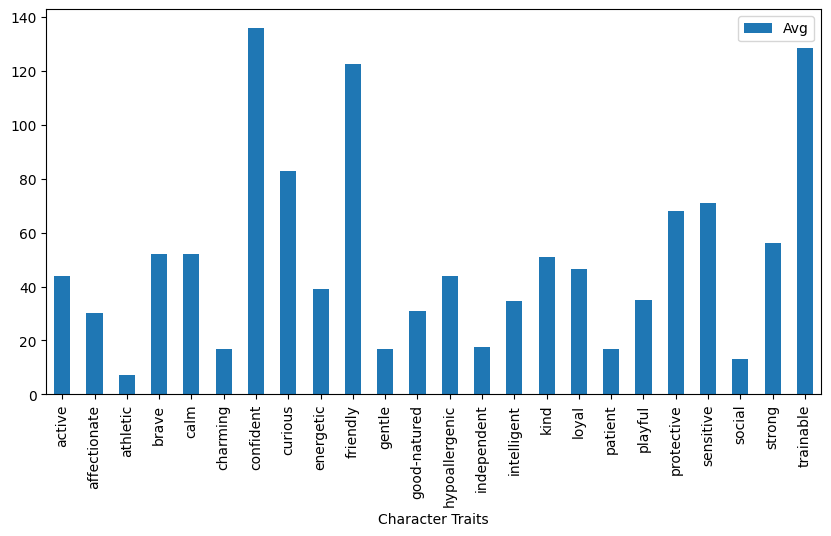

In [8]:
trait_vs_bite = conclusion_df[['Character Traits', 'Avg']]

trait_vs_bite.plot.bar(x='Character Traits', y='Avg', figsize=(10, 5), rot=90)

top_3_most_dangerous = trait_vs_bite.sort_values(by='Avg', ascending=False).head(5)
top_3_most_safe = trait_vs_bite.sort_values(by='Avg', ascending=True).head(5)


In [9]:
top_3_most_dangerous['Breeds'] = top_3_most_dangerous.apply(
    lambda x: conclusion_df.loc[conclusion_df['Character Traits'] == x['Character Traits']]['Breeds With Bites'].iloc[
        0], axis=1)
top_3_most_dangerous = top_3_most_dangerous.explode('Breeds')
top_3_most_safe['Breeds'] = top_3_most_safe.apply(
    lambda x: conclusion_df.loc[conclusion_df['Character Traits'] == x['Character Traits']]['Breeds With Bites'].iloc[0],
    axis=1
)
top_3_most_safe = top_3_most_safe.explode('Breeds')


def find_bite_from_breed(row):
    breed = row['Breeds']
    print(breed)
    details = grouped_bites.loc[grouped_bites['NormalizedBreed'] == breed]
    print(details)

    return details

top_3_most_dangerous


,Character Traits,Avg,Breeds
6,confident,136.000000,Rottweiler
6,confident,136.000000,Shih Tzu
6,confident,136.000000,German Shepherd
6,confident,136.000000,Chihuahua
23,trainable,128.500000,German Shepherd
23,trainable,128.500000,Collie
9,friendly,122.666667,Labrador Retriever
9,friendly,122.666667,Golden Retriever
9,friendly,122.666667,Beagle
7,curious,83.000000,Dachshund


In [10]:
def insert_bite_from_breed(row):
    breed = row['Breeds']
    details = grouped_bites.loc[grouped_bites['NormalizedBreed'] == breed]
    return details['Times'].iloc[0]

top_3_most_dangerous['Bites'] = top_3_most_dangerous.apply(lambda x: insert_bite_from_breed(x), axis=1)
top_3_most_safe['Bites'] = top_3_most_safe.apply(lambda x: insert_bite_from_breed(x), axis=1)
top_3_most_dangerous

,Character Traits,Avg,Breeds,Bites
6,confident,136.000000,Rottweiler,64
6,confident,136.000000,Shih Tzu,99
6,confident,136.000000,German Shepherd,246
6,confident,136.000000,Chihuahua,135
23,trainable,128.500000,German Shepherd,246
23,trainable,128.500000,Collie,11
9,friendly,122.666667,Labrador Retriever,225
9,friendly,122.666667,Golden Retriever,51
9,friendly,122.666667,Beagle,92
7,curious,83.000000,Dachshund,74


In [11]:
grouped_bites_safe = top_3_most_safe.groupby('Character Traits').agg({'Bites': 'sum'}).reset_index()
grouped_bites_danger = top_3_most_dangerous.groupby('Character Traits').agg({'Bites': 'sum'}).reset_index()
top_3_most_dangerous['Bites_N'] = 0.0
for i in range(len(top_3_most_dangerous)):
    target_trait = top_3_most_dangerous.iloc[i]['Character Traits']
    breed_bites = int(top_3_most_dangerous.iloc[i]['Bites'])
    total_bites_breed = int(grouped_bites_danger.loc[grouped_bites_danger['Character Traits'] == target_trait]['Bites'].iloc[0])

    top_3_most_dangerous.at[top_3_most_dangerous.index[i], 'Bites_N'] = breed_bites / total_bites_breed

top_3_most_safe['Bites_N'] = 0.0
for i in range(len(top_3_most_safe)):
    target_trait = top_3_most_safe.iloc[i]['Character Traits']
    breed_bites = int(top_3_most_safe.iloc[i]['Bites'])
    total_bites_breed = int(grouped_bites_safe.loc[grouped_bites_safe['Character Traits'] == target_trait]['Bites'].iloc[0])

    top_3_most_safe.at[top_3_most_safe.index[i], 'Bites_N'] = breed_bites / total_bites_breed


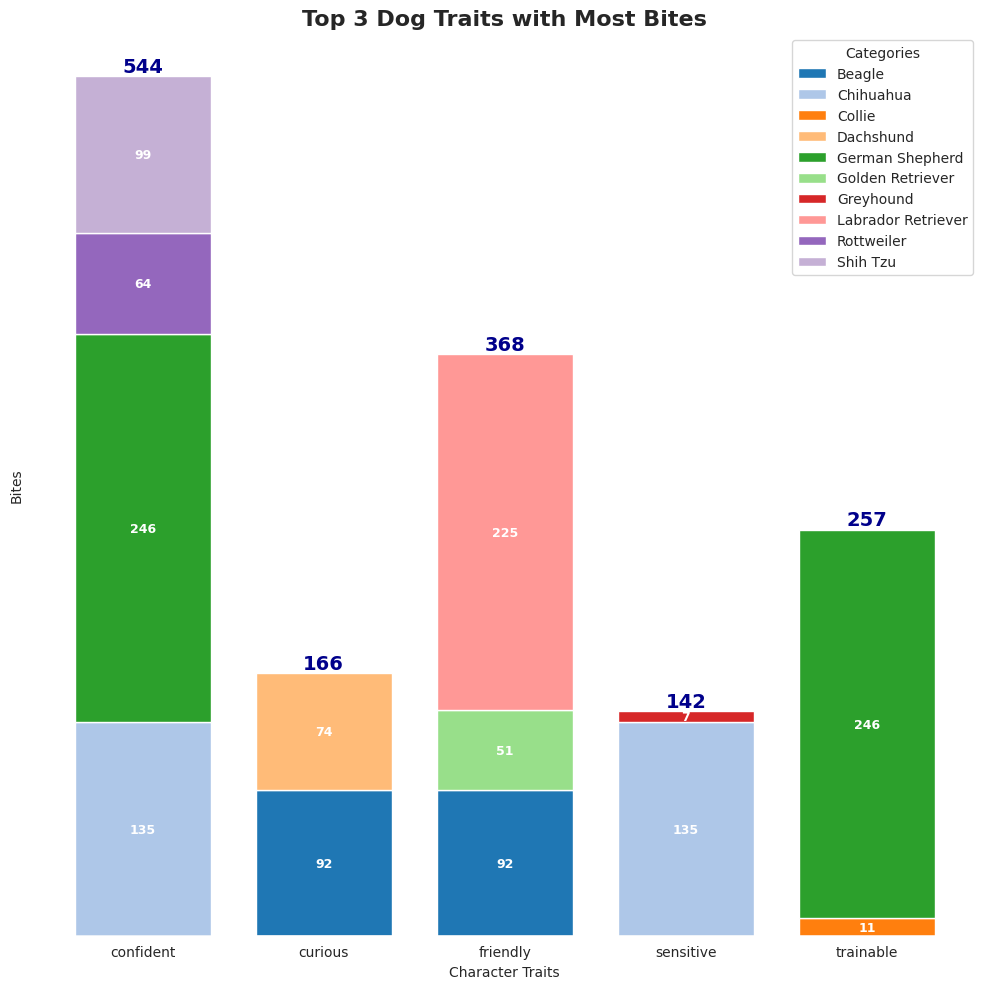

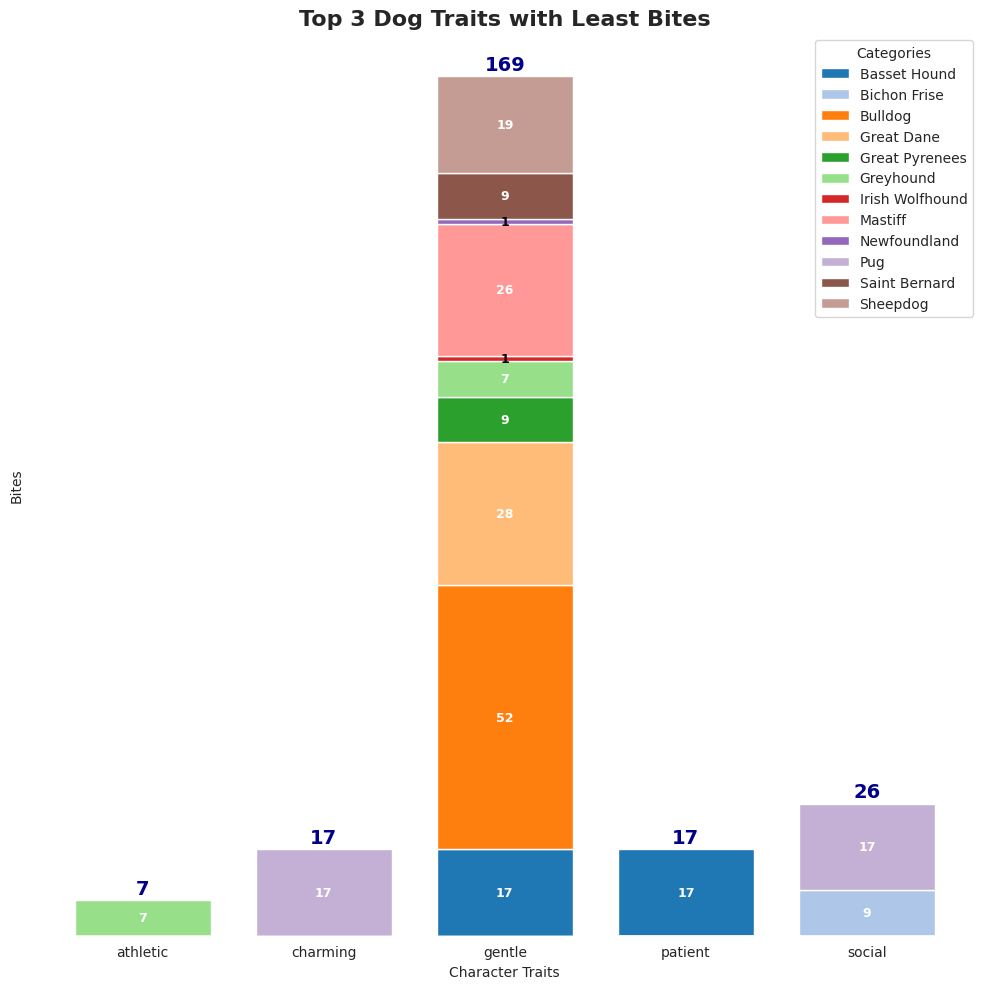

In [12]:
plot_danger_data = top_3_most_dangerous.pivot(index='Character Traits', columns='Breeds', values='Bites')



sns.set_style("whitegrid")
sns.set_palette("tab20")
def plot_tacked_bar(data, title):
    ax = data.plot(kind='bar', stacked=True, figsize=(10, 10), width=0.75)

    ax.grid(False)                    # Remove grid
    ax.spines['top'].set_visible(False)     # Remove top axis line
    ax.spines['right'].set_visible(False)   # Remove right axis line
    ax.spines['left'].set_visible(False)    # Remove left axis line
    ax.spines['bottom'].set_visible(False)  # Remove bottom axis line
    ax.set_yticks([])
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Character Traits')
    plt.ylabel('Bites')
    plt.xticks(rotation=0)
    plt.legend(title='Categories')

    # Add total values on top of bars
    totals = data.sum(axis=1)  # Calculate totals for each character trait
    for i, (trait, total) in enumerate(totals.items()):

        ax.text(i, total + 0.5, str(int(total)),
                ha='center',
                va='bottom',
                fontweight='bold',
                fontsize=14,
                color='darkblue',
                # bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
                )

    # Add individual values inside each stack segment
    cumulative = data.cumsum(axis=1)  # Calculate cumulative sums for positioning


    for i, trait in enumerate(data.index):
        for j, col in enumerate(data.columns):
            value = data.loc[trait, col]
            if value > 0:
                # Position text in the middle of each segment using cumulative values
                cum_value = cumulative.loc[trait, col]
                y_pos = cum_value - (value / 2)  # Middle of the current segment

                ax.text(i, y_pos, str(int(value)),
                        ha='center', va='center', fontweight='bold',
                        color='white' if value > 3 else 'black',
                        fontsize=9)

    plt.tight_layout()

    plt.savefig(f'{title}.png', dpi=400, bbox_inches='tight')
    plt.show()

plot_tacked_bar(plot_danger_data, 'Top 3 Dog Traits with Most Bites')
plot_safe_date = top_3_most_safe.pivot(index='Character Traits', columns='Breeds', values='Bites')
plot_tacked_bar(plot_safe_date, 'Top 3 Dog Traits with Least Bites')
